# Enhanced Federated Learning Pipeline (Codespaces Driver)

This Codespaces-ready notebook focuses on essentials to start and monitor FL training.
Core modules are imported from standalone Python files in this workspace.

## 1) Environment and Paths (Codespaces)
Set workspace-first paths and conservative dataset caps before running the pipeline.

In [ ]:
%pip install numpy tensorflow

import os
import random
from pathlib import Path

import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Reduce memory spikes from graph JIT/XLA.
tf.config.optimizer.set_jit(False)

WORKDIR = Path.cwd()

# Codespaces-first local paths.
FRAMES_CANDIDATES = [
    WORKDIR / "ffpp_frames",
    Path("/workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/ffpp_frames"),
]
FRAMES_DIR = next((p for p in FRAMES_CANDIDATES if p.exists()), FRAMES_CANDIDATES[0])

MODEL_CANDIDATES = [
    WORKDIR / "efficientnetb4_final.keras",
    Path("/workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/efficientnetb4_final.keras"),
    Path("efficientnetb4_final.keras"),
]
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])

# Smaller eval sets to reduce RAM pressure.
MAX_VAL_SAMPLES = 512
MAX_TEST_SAMPLES = 256

print(f"Workspace: {WORKDIR}")
print(f"Frames dir selected: {FRAMES_DIR}")
print(f"Frames dir exists: {FRAMES_DIR.exists()}")
print(f"Model path selected: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")

Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1777262994.941358  120899 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777262994.990515  120899 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777262996.399880  120899 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Workspace: /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection
Frames dir selected: /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/ffpp_frames
Frames dir exists: True
Model path selected: /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/efficientnetb4_final.keras
Model exists: True


## 2) Verify Required Modules
These files were extracted from the old notebook and are now imported directly.

In [2]:
required_modules = [
    "enhanced_client_selection.py",
    "update_validation.py",
    "knowledge_distillation.py",
    "client_reputation_ledger.py",
    "evaluation_metrics.py",
    "federated_learning_cycle.py",
]

missing = [m for m in required_modules if not Path(m).exists()]
if missing:
    raise FileNotFoundError(f"Missing module files: {missing}")

print("All required module files are present.")

All required module files are present.


## 3) Build Capped Datasets
Creates lightweight val/test/proxy/sup datasets from frame paths using generator-backed tf.data pipelines.

In [ ]:
import glob

all_paths = sorted(glob.glob(str(FRAMES_DIR / "**/*.jpg"), recursive=True))
assert len(all_paths) > 0, f"No frames found in {FRAMES_DIR}"

def _path_to_label(path: str) -> np.float32:
    return np.float32(1.0 if "fake" in path.lower() else 0.0)

real_paths = [p for p in all_paths if _path_to_label(p) == 0.0]
fake_paths = [p for p in all_paths if _path_to_label(p) == 1.0]

rng = np.random.RandomState(SEED)
rng.shuffle(real_paths)
rng.shuffle(fake_paths)

n_total = len(real_paths) + len(fake_paths)

n_val = min(max(1, int(n_total * 0.15)), MAX_VAL_SAMPLES)
n_test = min(max(1, int(n_total * 0.10)), MAX_TEST_SAMPLES)
n_proxy = max(1, int(n_total * 0.015))
n_sup = max(1, int(n_total * 0.02))
MAX_TRAIN_SAMPLES = 2000

def _get_balanced_split(count, real_list, fake_list):
    half = count // 2
    split_real = real_list[:half]
    split_fake = fake_list[:half]
    del real_list[:half]
    del fake_list[:half]
    combined_paths = split_real + split_fake
    combined_labels = [0.0]*len(split_real) + [1.0]*len(split_fake)
    
    # Shuffle the combined split
    idx = rng.permutation(len(combined_paths))
    shuffled_paths = [combined_paths[i] for i in idx]
    shuffled_labels = [np.float32(combined_labels[i]) for i in idx]
    return shuffled_paths, shuffled_labels

val_paths, val_labels = _get_balanced_split(n_val, real_paths, fake_paths)
test_paths, test_labels = _get_balanced_split(n_test, real_paths, fake_paths)
proxy_paths, _ = _get_balanced_split(n_proxy, real_paths, fake_paths)
sup_paths, sup_labels = _get_balanced_split(n_sup, real_paths, fake_paths)

# Remaining samples become federated client training data.
train_paths, train_labels = _get_balanced_split(MAX_TRAIN_SAMPLES, real_paths, fake_paths)

assert len(train_paths) > 0, "No training samples left after split; reduce val/test/proxy/sup caps."

print(
    f"Datasets built: train={len(train_paths)}, val={len(val_paths)}, "
    f"test={len(test_paths)}, proxy={len(proxy_paths)}, sup={len(sup_paths)}"
)

MODEL_IMG_SIZE = (224, 224)
if MODEL_PATH.exists():
    try:
        _tmp_model = tf.keras.models.load_model(MODEL_PATH, compile=False)
        MODEL_IMG_SIZE = tuple(_tmp_model.input_shape[1:3])
        del _tmp_model
    except Exception as e:
        print(f"Model load warning (using default 224x224): {e}")

def _load_image(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.cast(tf.image.resize(img, MODEL_IMG_SIZE), tf.float16)  # MEMORY FIX: cast to float16
    return img, label

def _load_image_only(path):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.cast(tf.image.resize(img, MODEL_IMG_SIZE), tf.float16)  # MEMORY FIX: cast to float16
    return img

def _ds_from_paths_labels(paths, labels):
    return tf.data.Dataset.from_generator(
        lambda: ((p, np.float32(y)) for p, y in zip(paths, labels)),
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),
            tf.TensorSpec(shape=(), dtype=tf.float32),
        ),
    )

def _ds_from_paths(paths):
    return tf.data.Dataset.from_generator(
        lambda: (p for p in paths),
        output_signature=tf.TensorSpec(shape=(), dtype=tf.string),
    )

train_ds = _ds_from_paths_labels(train_paths, train_labels).map(_load_image, num_parallel_calls=1)
val_ds = _ds_from_paths_labels(val_paths, val_labels).map(_load_image, num_parallel_calls=1)
test_ds = _ds_from_paths_labels(test_paths, test_labels).map(_load_image, num_parallel_calls=1)
proxy_ds = _ds_from_paths(proxy_paths).map(_load_image_only, num_parallel_calls=1)
sup_ds = _ds_from_paths_labels(sup_paths, sup_labels).map(_load_image, num_parallel_calls=1)

Datasets built: train=1000, val=256, test=128, proxy=475, sup=633


E0000 00:00:1777262996.999144  120899 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 4) Configure and Start FL Pipeline
Imports only the orchestrator and config objects needed to run training.

In [ ]:
from federated_learning_cycle import (
    FLCycleConfig,
    FederatedLearningCycle,
)
from knowledge_distillation import DistillationConfig

config = FLCycleConfig(
    model_path=str(MODEL_PATH),
    reports_dir="reports",
    num_devices=20,
    clients_per_round=4,
    local_epochs=2,
    global_rounds=10,
    local_batch_size=8,
    enable_distillation=True,
    distillation_config=DistillationConfig(batch_size=4, epochs=1),
    validator_max_eval_batches=1,
    eval_every=10,
)

cycle = FederatedLearningCycle(config)
_ = cycle.load_global_model()

# Build federated client partitions from path lists (works with generator-backed datasets).
train_size = len(train_paths)
if train_size == 0:
    raise ValueError("Training split is empty; re-run Cell 9 and verify frame paths.")

num_clients = int(config.num_devices)
if train_size < num_clients:
    print(f"Warning: train samples ({train_size}) < num clients ({num_clients}); some clients get 1 sample.")

indices = np.arange(train_size)
np.random.seed(SEED)
np.random.shuffle(indices)
splits = np.array_split(indices, num_clients)

client_data = {}
for i, split_idx in enumerate(splits):
    cid = f"client_{i}"
    if len(split_idx) == 0:
        # Keep every client non-empty to avoid downstream edge cases.
        split_idx = np.array([indices[i % train_size]])
    c_paths = [train_paths[j] for j in split_idx]
    c_labels = [train_labels[j] for j in split_idx]
    client_data[cid] = _ds_from_paths_labels(c_paths, c_labels).map(
        _load_image, num_parallel_calls=1
    )

_ = cycle.create_clients(client_data)
cycle.setup_components()

print(
    f"Cycle initialized with {len(cycle.clients)} clients | "
    f"clients/round={config.clients_per_round}, rounds={config.global_rounds}, "
    f"local_epochs={config.local_epochs}"
)

2026-04-27 04:10:00,770 | INFO     | Loading global model from /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/efficientnetb4_final.keras …


2026-04-27 04:10:03,203 | INFO     | Global model loaded — 20,394,336 params, input shape (None, 260, 260, 3)
I0000 00:00:1777263003.667798  120899 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
2026-04-27 04:10:06,670 | INFO     | Created 20 federated clients.
2026-04-27 04:10:06,671 | INFO     | All FL-cycle components initialised.


Cycle initialized with 20 clients | clients/round=4, rounds=30, local_epochs=2


In [5]:
import gc
import json
from pathlib import Path

import tensorflow as tf
from client_reputation_ledger import ClientReputationLedger
from federated_learning_cycle import convert_to_tflite

CKPT_DIR = WORKDIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path(config.reports_dir)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LATEST_CKPT = CKPT_DIR / "latest_checkpoint.json"
HISTORY_FILE = CKPT_DIR / "history.json"
LEDGER_FILE = CKPT_DIR / "reputation_ledger.json"

# Keep recent checkpoint files only to limit disk/page-cache pressure.
MAX_CHECKPOINT_FILES = 3

# Export flags are disabled by default to avoid end-of-run kernel crashes.
# Run export in a separate fresh phase/cell for best stability.
EXPORT_TFLITE_AT_END = False
EXPORT_QUANTISED_AT_END = False

def _prune_old_weight_checkpoints(keep_last_n: int = MAX_CHECKPOINT_FILES) -> None:
    weight_files = sorted(CKPT_DIR.glob("round_*.weights.h5"))
    if len(weight_files) <= keep_last_n:
        return
    for stale in weight_files[:-keep_last_n]:
        try:
            stale.unlink()
        except Exception as e:
            print(f"Checkpoint cleanup warning for {stale.name}: {e}")

def _save_checkpoint(round_idx: int) -> None:
    weights_file = CKPT_DIR / f"round_{round_idx:03d}.weights.h5"
    cycle.global_model.save_weights(str(weights_file))
    if cycle.reputation_ledger is not None:
        cycle.reputation_ledger.save(str(LEDGER_FILE))
    HISTORY_FILE.write_text(json.dumps(cycle.history), encoding="utf-8")
    meta = {
        "round": int(round_idx),
        "weights_file": weights_file.name,
        "history_file": HISTORY_FILE.name,
        "ledger_file": LEDGER_FILE.name,
    }
    LATEST_CKPT.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    _prune_old_weight_checkpoints()

def _restore_if_available() -> int:
    if not LATEST_CKPT.exists():
        return 0
    meta = json.loads(LATEST_CKPT.read_text(encoding="utf-8"))
    last_round = int(meta.get("round", 0))
    weights_file = CKPT_DIR / meta.get("weights_file", "")
    if weights_file.exists():
        cycle.global_model.load_weights(str(weights_file))
        if cycle.validator is not None:
            cycle.validator.global_model.set_weights(cycle.global_model.get_weights())
    if HISTORY_FILE.exists():
        cycle.history = json.loads(HISTORY_FILE.read_text(encoding="utf-8"))
    if LEDGER_FILE.exists():
        restored = ClientReputationLedger.load(str(LEDGER_FILE))
        cycle.reputation_ledger = restored
        cycle.basic_ledger = restored.as_basic_ledger()
        if cycle.selector is not None:
            cycle.selector.reputation_ledger = cycle.basic_ledger
        if cycle.validator is not None:
            cycle.validator.ledger = cycle.basic_ledger
    print(f"Resuming from checkpoint after round {last_round}.")
    return last_round + 1

def _safe_tflite_export(global_model, output_path: str, quantise: bool) -> None:
    # Clear stale TF execution state before heavy conversion.
    tf.keras.backend.clear_session()
    gc.collect()
    convert_to_tflite(global_model, output_path, quantise=quantise)
    gc.collect()

start_round = _restore_if_available()
all_reports = []

if start_round == 0:
    print("No checkpoint found. Starting fresh run.")
    baseline_report = cycle.evaluator.evaluate(
        test_data=test_ds.take(128),
        batch_size=config.local_batch_size,
        federated_round=0,
        extra_info={"stage": "baseline", "eval_mode": "lightweight"},
        full_metrics=False,
        run_latency=False,
        max_samples_for_periodic_auc=128,
    )
    cycle.evaluator.save_report(baseline_report, tag="round_000_baseline")
    all_reports.append(baseline_report)
    _save_checkpoint(0)
    start_round = 1

for t in range(start_round, config.global_rounds + 1):
    info = cycle.execute_round(
        current_round=t,
        server_val_data=val_ds,
        proxy_data=(None if not config.enable_distillation else proxy_ds),
        supervised_data=(None if not config.enable_distillation else sup_ds),
    )

    cycle.history["round"].append(t)
    cycle.history["global_accuracy"].append(info["global_accuracy"])
    cycle.history["selected_clients"].append(info["selected"])
    cycle.history["num_accepted"].append(info["num_accepted"])
    cycle.history["num_rejected"].append(info["num_rejected"])
    cycle.history["distillation_loss"].append(info["distillation_loss"])

    is_eval_round = (t % config.eval_every == 0) or (t == 1) or (t == config.global_rounds)
    if is_eval_round:
        is_final_round = t == config.global_rounds
        eval_mode = "full" if is_final_round else "lightweight"
        eval_data = test_ds if is_final_round else test_ds.take(128)
        report = cycle.evaluator.evaluate(
            test_data=eval_data,
            batch_size=config.local_batch_size,
            federated_round=t,
            latency_max_batches=(None if is_final_round else 2),
            extra_info={
                "accepted": info["num_accepted"],
                "rejected": info["num_rejected"],
                "distillation_loss": info["distillation_loss"],
                "eval_mode": eval_mode,
            },
            full_metrics=is_final_round,
            run_latency=is_final_round,
            max_samples_for_periodic_auc=128,
        )
        cycle.evaluator.save_report(report, tag=f"round_{t:03d}")
        all_reports.append(report)

    _save_checkpoint(t)
    tf.keras.backend.clear_session()
    gc.collect()

if len(cycle.history.get("round", [])) >= config.global_rounds:
    if len(all_reports) > 1:
        cycle.evaluator.save_comparison_report(all_reports)
    if cycle.reputation_ledger is not None:
        cycle.reputation_ledger.save(str(REPORTS_DIR / "reputation_ledger_final.json"))

    if EXPORT_TFLITE_AT_END:
        _safe_tflite_export(
            cycle.global_model,
            config.tflite_output_path,
            quantise=False,
        )

        if EXPORT_QUANTISED_AT_END:
            _safe_tflite_export(
                cycle.global_model,
                config.tflite_output_path.replace(".tflite", "_quantised.tflite"),
                quantise=True,
            )
    else:
        print(
            "Skipped TFLite export in training cell for stability. "
            "Run the export cell after this in a fresh kernel/session."
        )

    cycle._print_summary()
else:
    print("Training paused before completion; resume by running this cell again.")

history = cycle.history
print("Training complete. History keys:", list(history.keys()))

2026-04-27 04:10:08,323 | INFO     | Ledger loaded from /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/checkpoints/reputation_ledger.json (60 clients).
2026-04-27 04:10:08,325 | INFO     | ======================================================================
2026-04-27 04:10:08,325 | INFO     |   ROUND 7 / 30
2026-04-27 04:10:08,326 | INFO     | ======================================================================
2026-04-27 04:10:08,329 | INFO     | Round 7 — selected 4 / 20 clients: ['client_7', 'client_2', 'client_6', 'client_17']
2026-04-27 04:10:08,330 | INFO     | Selected 4 / 20 clients: ['client_7', 'client_2', 'client_6', 'client_17']


Resuming from checkpoint after round 6.


W0000 00:00:1777263032.390403  121450 cpu_allocator_impl.cc:82] Allocation of 77875200 exceeds 10% of free system memory.
W0000 00:00:1777263032.409198  121450 cpu_allocator_impl.cc:82] Allocation of 77875200 exceeds 10% of free system memory.
W0000 00:00:1777263032.440913  121450 cpu_allocator_impl.cc:82] Allocation of 79077888 exceeds 10% of free system memory.
W0000 00:00:1777263033.689054  121449 cpu_allocator_impl.cc:82] Allocation of 77875200 exceeds 10% of free system memory.
W0000 00:00:1777263033.702257  121449 cpu_allocator_impl.cc:82] Allocation of 77875200 exceeds 10% of free system memory.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-04-27 04:11:43,974 | IN

KeyboardInterrupt: 

In [6]:
import gc
import tensorflow as tf
from federated_learning_cycle import convert_to_tflite

EXPORT_STANDARD = True
EXPORT_QUANTISED = False

if not (EXPORT_STANDARD or EXPORT_QUANTISED):
    print("No exports selected. Set EXPORT_STANDARD and/or EXPORT_QUANTISED to True.")
else:
    # Ensure model object is present before conversion.
    if "cycle" not in globals() or cycle.global_model is None:
        raise RuntimeError(
            "Global model is not loaded. Run training setup/restore cells first, then retry export."
        )

    if EXPORT_STANDARD:
        convert_to_tflite(
            cycle.global_model,
            config.tflite_output_path,
            quantise=False,
        )
        gc.collect()

    if EXPORT_QUANTISED:
        convert_to_tflite(
            cycle.global_model,
            config.tflite_output_path.replace(".tflite", "_quantised.tflite"),
            quantise=True,
        )
        gc.collect()

    tf.keras.backend.clear_session()
    gc.collect()

    print("Export step complete.")

INFO:tensorflow:Assets written to: /tmp/tmppdjxsliq/assets


2026-04-27 05:26:25,663 | INFO     | Assets written to: /tmp/tmppdjxsliq/assets


Saved artifact at '/tmp/tmppdjxsliq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  123819930492112: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  123819930490960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  123820487756112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487758224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487757456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487754960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487758416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487758608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123820487754384: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1777267589.663807  120899 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777267589.664603  120899 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777267589.670317  120899 reader.cc:83] Reading SavedModel from: /tmp/tmppdjxsliq
I0000 00:00:1777267589.704926  120899 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777267589.704951  120899 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmppdjxsliq
I0000 00:00:1777267589.998747  120899 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1777267590.055867  120899 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777267591.643968  120899 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmppdjxsliq
I0000 00:00:1777267592.072050  120899 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 2401749 microseconds.
I0000 00:00:1777267593.013867  1208

Export step complete.


## 5) Export TFLite Notes
Use Cell 13 (the export code cell above) after training completes. For best stability, restart the kernel and restore the checkpoint before running export.

In [ ]:
# Optional cleanup: delete reports and checkpoints.
#import shutil
#from pathlib import Path

#workdir = globals().get("WORKDIR", Path.cwd())

#for p in [workdir / "reports", workdir / "checkpoints"]:
#    if p.exists():
        shutil.rmtree(p)
        print(f"Deleted: {p}")
#    else:
#        print(f"Not found: {p}")

Deleted: /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/reports
Deleted: /workspaces/Enhanced-Federated-Learning-Cycle-for-DeepFake-Detection/checkpoints


## 7. Evaluate and Visualize Results

Here, we will load the saved results from the `checkpoints/` and `reports/` directories and visualize the federated learning metrics. This includes:
- Global model accuracy and distillation loss over rounds.
- The reputation distribution among clients.
- Final model performance based on the evaluation reports.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 56.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 48.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 49.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m8/9 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


2026-04-27 05:31:44,142 | INFO     | generated new fontManager


--- Federated Learning Training History ---


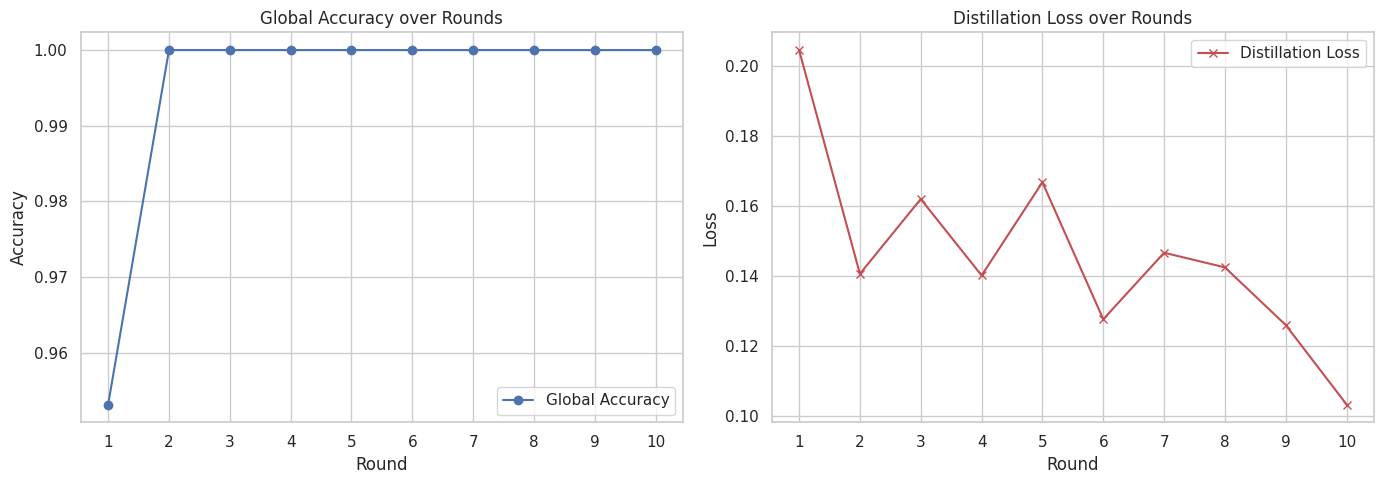


--- Client Reputation Distribution ---


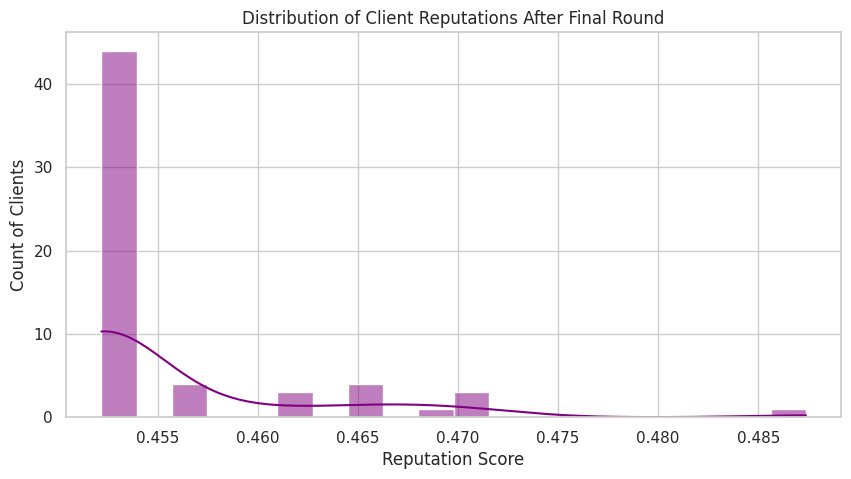

Top 5 Clients by Reputation:
  client_14: 0.4874
  client_1: 0.4707
  client_6: 0.4707
  client_17: 0.4707
  client_18: 0.4682

Bottom 5 Clients by Reputation:
  client_55: 0.4522
  client_56: 0.4522
  client_57: 0.4522
  client_58: 0.4522
  client_59: 0.4522

--- Final Model Evaluation Report ---
Loading report: reports/effnet_global_20260427_051424_round_010.json

Metrics:
  Accuracy:      1.0000
  F1 (Weighted): 1.0000
  F1 (Macro):    0.5000


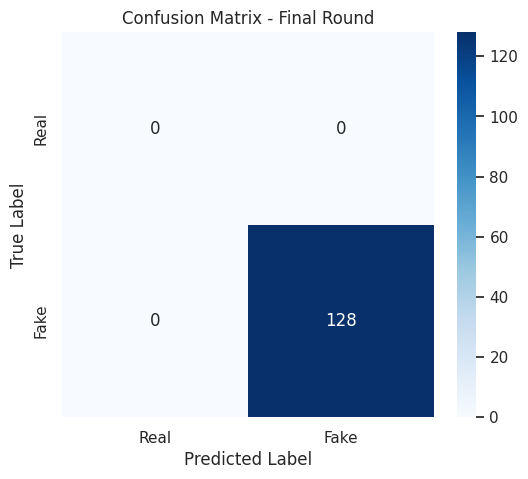

In [8]:
%pip install matplotlib seaborn

import os
import json
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply seaborn style for better visualization
sns.set_theme(style="whitegrid")

# Define paths
checkpoints_dir = "checkpoints"
reports_dir = "reports"
history_path = os.path.join(checkpoints_dir, "history.json")
reputation_path = os.path.join(checkpoints_dir, "reputation_ledger.json")

# 1. Visualize Training History (Accuracy and Loss)
print("--- Federated Learning Training History ---")
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
        
    rounds = history.get('round', [])
    accuracy = history.get('global_accuracy', [])
    dist_loss = history.get('distillation_loss', [])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy over rounds
    ax1.plot(rounds, accuracy, marker='o', color='b', label='Global Accuracy')
    ax1.set_title('Global Accuracy over Rounds')
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.set_xticks(rounds)
    
    # Loss over rounds
    ax2.plot(rounds, dist_loss, marker='x', color='r', label='Distillation Loss')
    ax2.set_title('Distillation Loss over Rounds')
    ax2.set_xlabel('Round')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.set_xticks(rounds)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"History file not found at {history_path}")

# 2. Visualize Client Reputations
print("\n--- Client Reputation Distribution ---")
if os.path.exists(reputation_path):
    with open(reputation_path, 'r') as f:
        reputation_data = json.load(f)
        
    entries = reputation_data.get('entries', {})
    reputations = [data['reputation'] for client, data in entries.items()]
    client_ids = list(entries.keys())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(reputations, bins=20, kde=True, ax=ax, color='purple')
    ax.set_title('Distribution of Client Reputations After Final Round')
    ax.set_xlabel('Reputation Score')
    ax.set_ylabel('Count of Clients')
    plt.show()
    
    # Show top 5 and bottom 5 clients
    sorted_clients = sorted(entries.items(), key=lambda x: x[1]['reputation'], reverse=True)
    print("Top 5 Clients by Reputation:")
    for client, data in sorted_clients[:5]:
        print(f"  {client}: {data['reputation']:.4f}")
        
    print("\nBottom 5 Clients by Reputation:")
    for client, data in sorted_clients[-5:]:
        print(f"  {client}: {data['reputation']:.4f}")
else:
    print(f"Reputation ledger not found at {reputation_path}")

# 3. Last Evaluation Report
print("\n--- Final Model Evaluation Report ---")
report_files = glob.glob(os.path.join(reports_dir, "*.json"))
if report_files:
    # Sort files by name to get the latest round report
    latest_report_file = sorted(report_files)[-1]
    print(f"Loading report: {latest_report_file}")
    
    with open(latest_report_file, 'r') as f:
        report_data = json.load(f)
        
    cls_metrics = report_data.get('classification', {})
    
    print("\nMetrics:")
    print(f"  Accuracy:      {cls_metrics.get('accuracy', 0):.4f}")
    print(f"  F1 (Weighted): {cls_metrics.get('f1_weighted', 0):.4f}")
    print(f"  F1 (Macro):    {cls_metrics.get('f1_macro', 0):.4f}")
    
    # Confusion Matrix
    cm = cls_metrics.get('confusion_matrix', [])
    if cm:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.title('Confusion Matrix - Final Round')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
else:
    print("No evaluation report files found in the 'reports' directory.")